In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from mpc.configs import *
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import imageio
import torch
from stable_baselines3 import TD3
import scipy.linalg

System eigenvalues: [1.         1.         1.0826774  0.92363617]
Starting simulation...
Initial angle: 11.5 degrees
Final angle: 1354.748 degrees
Max control force: 5.00 N


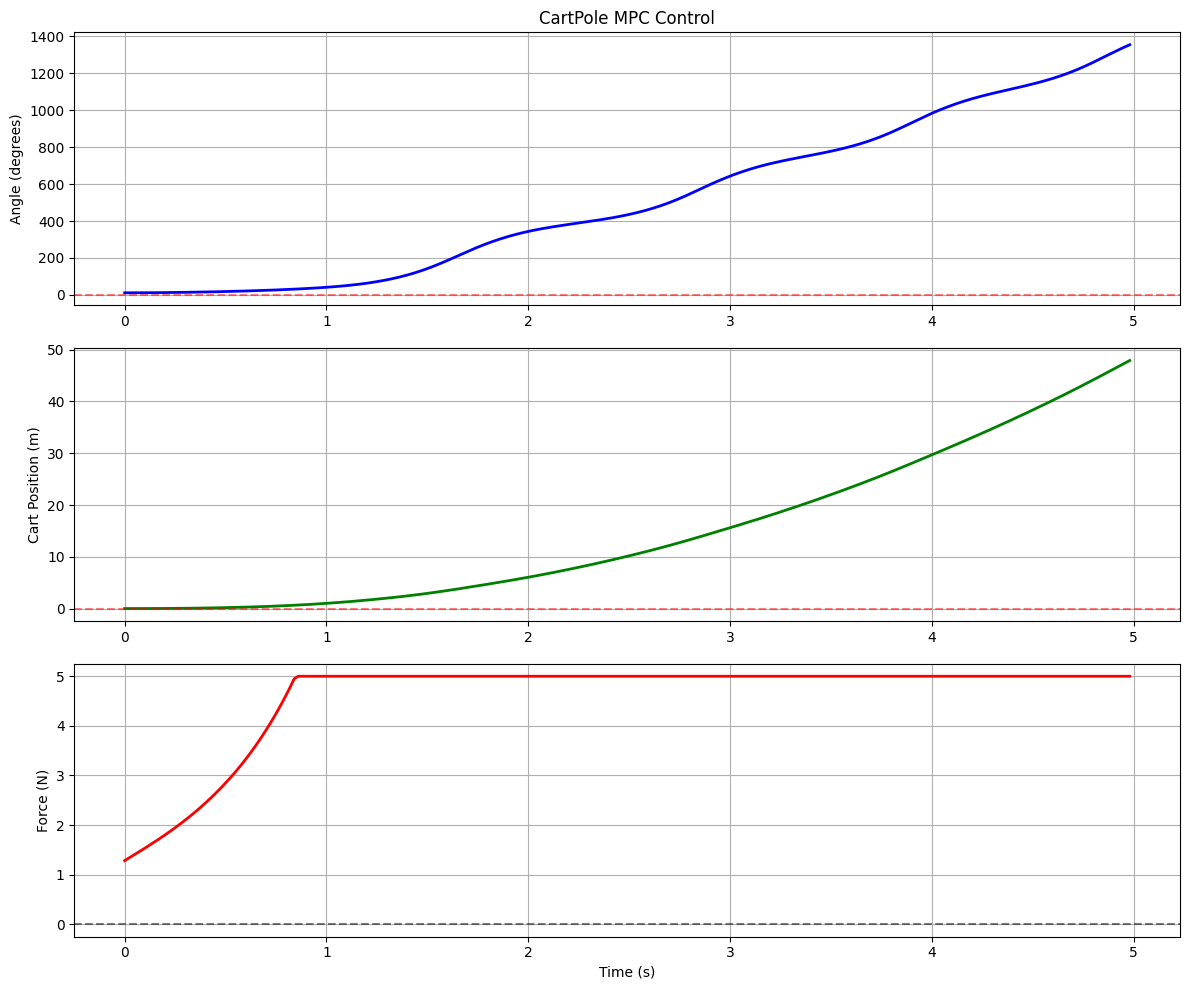


Stability metrics (last 1 second):
Angle std deviation: 101.290 degrees
Position std deviation: 5.359 m
✗ System not well stabilized


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

class CartPoleMPC:
    def __init__(self, dt=0.02, horizon=10):
        # Physical parameters
        self.g = 9.8
        self.m_cart = 1.0
        self.m_pole = 0.1
        self.l = 0.5  # pole half-length
        self.dt = dt
        self.horizon = horizon
        
        # Linearize around upright equilibrium
        self.A, self.B = self._linearize_system()
        
        # Cost matrices
        self.Q = np.diag([1.0, 10.0, 0.1, 0.5])  # [x, θ, ẋ, θ̇]
        self.R = np.array([[0.1]])               # control cost
        self.Q_terminal = 2.0 * self.Q
        
        # Equilibrium point
        self.x_eq = np.array([0.0, 0.0, 0.0, 0.0])
        self.u_eq = np.array([0.0])
        
        print(f"System eigenvalues: {np.linalg.eigvals(self.A)}")
        
    def _linearize_system(self):
        """Linearize cartpole dynamics around upright equilibrium."""
        M = self.m_cart + self.m_pole
        denom = self.l * (4/3 - self.m_pole / M)
        
        # Continuous-time linearized dynamics
        A_cont = np.array([
            [0, 0, 1, 0],
            [0, 0, 0, 1],
            [0, -self.m_pole * self.g / M, 0, 0],
            [0, self.g / denom, 0, 0]
        ])
        
        B_cont = np.array([
            [0],
            [0],
            [1 / M],
            [-1 / (M * denom)]
        ])
        
        # Discretize using matrix exponential
        AB = np.block([[A_cont, B_cont], 
                       [np.zeros((1, 5))]])
        exp_AB = scipy.linalg.expm(AB * self.dt)
        
        A_disc = exp_AB[:4, :4]
        B_disc = exp_AB[:4, 4:5]
        
        return A_disc, B_disc
    
    def _nonlinear_dynamics(self, state, action):
        """True nonlinear cartpole dynamics for simulation."""
        x, theta, x_dot, theta_dot = state
        force = action[0]
        
        # Nonlinear cartpole equations
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)
        
        M = self.m_cart + self.m_pole
        temp = (force + self.m_pole * self.l * theta_dot**2 * sin_theta) / M
        
        theta_acc = (self.g * sin_theta - cos_theta * temp) / \
                   (self.l * (4/3 - self.m_pole * cos_theta**2 / M))
        
        x_acc = temp - self.m_pole * self.l * theta_acc * cos_theta / M
        
        # Euler integration
        new_state = np.array([
            x + self.dt * x_dot,
            theta + self.dt * theta_dot,
            x_dot + self.dt * x_acc,
            theta_dot + self.dt * theta_acc
        ])
        
        return new_state
    
    def solve_mpc(self, current_state):
        """Solve finite horizon MPC using Riccati recursion."""
        N = self.horizon
        n_states = 4
        n_controls = 1
        
        # Backward pass: Riccati recursion
        P = [None] * (N + 1)
        K = [None] * N
        
        P[N] = self.Q_terminal
        
        for t in reversed(range(N)):
            try:
                # Compute gain
                BTPb = self.B.T @ P[t+1] @ self.B
                reg_matrix = self.R + BTPb
                
                # Add regularization if needed
                if np.linalg.cond(reg_matrix) > 1e10:
                    reg_matrix += 1e-6 * np.eye(n_controls)
                
                K[t] = np.linalg.solve(reg_matrix, self.B.T @ P[t+1] @ self.A)
                
                # Update cost-to-go
                P[t] = self.Q + self.A.T @ P[t+1] @ self.A - \
                       self.A.T @ P[t+1] @ self.B @ K[t]
                       
            except np.linalg.LinAlgError:
                # Fallback: use infinite horizon LQR
                print(f"Riccati failed at step {t}, using LQR fallback")
                P_inf = scipy.linalg.solve_discrete_are(self.A, self.B, self.Q, self.R)
                K[t] = np.linalg.solve(self.R + self.B.T @ P_inf @ self.B, 
                                     self.B.T @ P_inf @ self.A)
                P[t] = P_inf
        
        # Forward pass: compute optimal trajectory
        action_sequence = np.zeros((N, 1))
        state = current_state.copy()
        
        for t in range(N):
            state_error = state - self.x_eq
            action = -K[t] @ state_error + self.u_eq
            
            # Clip actions
            action = np.clip(action, -5.0, 5.0)
            action_sequence[t] = action
            
            # Propagate using linear model (for planning)
            state = self.A @ state + self.B @ action
        
        return action_sequence
    
    def simulate(self, initial_state, duration=5.0):
        """Simulate closed-loop system with MPC control."""
        time_steps = int(duration / self.dt)
        
        # Storage
        states = np.zeros((time_steps, 4))
        actions = np.zeros((time_steps, 1))
        times = np.zeros(time_steps)
        
        # Initial condition
        state = initial_state.copy()
        
        for t in range(time_steps):
            # Store current state
            states[t] = state
            times[t] = t * self.dt
            
            # Solve MPC
            action_sequence = self.solve_mpc(state)
            
            # Apply first action (receding horizon)
            action = action_sequence[0]
            actions[t] = action
            
            # Simulate forward using TRUE nonlinear dynamics
            state = self._nonlinear_dynamics(state, action)
            
            # Optional: add some noise
            # state += 0.001 * np.random.randn(4)
        
        return times, states, actions

def plot_results(times, states, actions):
    """Plot simulation results."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Plot 1: Angle over time
    axes[0].plot(times, states[:, 1] * 180/np.pi, 'b-', linewidth=2)
    axes[0].set_ylabel('Angle (degrees)')
    axes[0].set_title('CartPole MPC Control')
    axes[0].grid(True)
    axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    
    # Plot 2: Position over time
    axes[1].plot(times, states[:, 0], 'g-', linewidth=2)
    axes[1].set_ylabel('Cart Position (m)')
    axes[1].grid(True)
    axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    
    # Plot 3: Control action over time
    axes[2].plot(times, actions[:, 0], 'r-', linewidth=2)
    axes[2].set_ylabel('Force (N)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True)
    axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Create MPC controller
    mpc = CartPoleMPC(dt=0.02, horizon=10)
    
    # Initial condition: pole slightly tilted
    initial_state = np.array([
        0.0,    # cart position
        0.2,    # pole angle (radians) ≈ 11.5 degrees  
        0.0,    # cart velocity
        0.0     # pole angular velocity
    ])
    
    print("Starting simulation...")
    print(f"Initial angle: {initial_state[1] * 180/np.pi:.1f} degrees")
    
    # Run simulation
    times, states, actions = mpc.simulate(initial_state, duration=5.0)
    
    # Print final results
    final_angle = states[-1, 1] * 180/np.pi
    print(f"Final angle: {final_angle:.3f} degrees")
    print(f"Max control force: {np.max(np.abs(actions)):.2f} N")
    
    # Plot results
    plot_results(times, states, actions)
    
    # Check stability
    final_states = states[-50:]  # Last 1 second
    angle_std = np.std(final_states[:, 1]) * 180/np.pi
    position_std = np.std(final_states[:, 0])
    
    print(f"\nStability metrics (last 1 second):")
    print(f"Angle std deviation: {angle_std:.3f} degrees")
    print(f"Position std deviation: {position_std:.3f} m")
    
    if angle_std < 1.0 and position_std < 0.1:
        print("✓ System successfully stabilized!")
    else:
        print("✗ System not well stabilized")